# Exercise - The Steepener Trade

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

A popular trade in 2024 was the **2-10 steepener** trade, which was a trade designed to capture the changes in the slope of yield curve while being hedged to parallel shifts in it. 

In particular, the trade believes that the 2-year treasury yield is too high relative to the 10-year treasury yield. 

### The Trade

You will be putting on a trade with `50 million` notional long in the `2yr`. As always, consider the size of each bond to be `100` face value.

### Data

Find the data in 
`data/steepener_trade_2024-01-02.xlsx`
* `info` - info about the two treasuries
* `clean` - timeseries of clean prices
* `dirty` - timeseries of dirty prices
* `duration` - timeseries of duration
* `database` - combined data of everything - no need to use this

We'll mostly work with the **dirty** prices, but you may find the clean prices useful in the last problem.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

#DATE = '2023-06-30'
DATE = '2024-01-02'

FILE_DATA = f'steepener_trade_{DATE}.xlsx'

info = pd.read_excel(FILE_DATA,sheet_name='info').set_index('KYTREASNO').T
clean = pd.read_excel(FILE_DATA,sheet_name='clean price').set_index('quote date')
dirty = pd.read_excel(FILE_DATA,sheet_name='dirty price').set_index('quote date')
duration = pd.read_excel(FILE_DATA,sheet_name='duration').set_index('quote date')

In [32]:
display(info)

KYTREASNO,207652,208147
type,note,note
quote date,2024-01-02 00:00:00,2024-01-02 00:00:00
issue date,2020-12-31 00:00:00,2023-11-15 00:00:00
maturity date,2025-12-31 00:00:00,2033-11-15 00:00:00
ttm,1.995893,9.869952
accrual fraction,0.010989,0.263736
cpn rate,0.375,4.5
bid,92.578125,104.578125
ask,92.59375,104.640625
price,92.585938,104.609375


In [33]:
display(dirty.tail().style.format('{:.2f}').format_index('{:%Y-%m-%d}').set_caption('Dirty Prices'))
display(duration.tail().style.format('{:.2f}').format_index('{:%Y-%m-%d}').set_caption('Duration'))

,207652,208147
quote date,,
2025-05-23,97.90,100.76
2025-05-27,97.91,101.22
2025-05-28,97.91,100.97
2025-05-29,97.92,101.40
2025-05-30,97.95,101.69


,207652,208147
quote date,,
2025-05-23,0.61,7.15
2025-05-27,0.60,7.14
2025-05-28,0.59,7.14
2025-05-29,0.59,7.14
2025-05-30,0.59,7.14


### 1.1.

Consider the first date of the sample for which you have prices and duration data.

Construct the trade such that you are zero net dollar duration.

* What is the dollar value of your short position (against your 50 million long.)
* How many 2-year bonds? (Assume you can have fractional bonds.)
* How many 10-year bonds? (Assume you can have fractional bonds.)

#### Note
For price calculations, use the dirty price.

In [34]:
# Size 2–10 steepener to be zero net dollar duration (using dirty prices)
NOTIONAL_LONG_2Y = 50_000_000.0   # $ face notional long in the 2Y leg
FACE_PER_BOND = 100.0

ids = list(dirty.columns.intersection(duration.columns))
dirty2 = dirty[ids]
dur2   = duration[ids]

# first date with both dirty prices + durations for both bonds
valid = dirty2.notna().all(axis=1) & dur2.notna().all(axis=1)
first_dt = valid.idxmax()

p = dirty2.loc[first_dt]   # dirty prices per $100 face
D = dur2.loc[first_dt]     # durations (years)

# identify 2Y vs 10Y (fallback: larger duration = 10Y)
id_10y = D.idxmax()
id_2y  = D.idxmin()

# long 2Y: bonds, market value, dollar duration
n2 = NOTIONAL_LONG_2Y / FACE_PER_BOND
MV2 = n2 * p[id_2y]
DD2 = MV2 * D[id_2y]

# short 10Y to neutralize dollar duration: MV10 = MV2*D2 / D10
MV10 = DD2 / D[id_10y]
n10 = MV10 / p[id_10y]  # number of 10Y bonds to short (magnitude)

out = pd.DataFrame(
    {
        "KYTREASNO": [id_2y, id_10y],
        "Leg": ["Long 2Y", "Short 10Y"],
        "Dirty Price": [p[id_2y], p[id_10y]],
        "Duration": [D[id_2y], D[id_10y]],
        "Bonds (#)": [n2, -n10],
        "Market Value ($)": [MV2, -MV10],
        "Dollar Duration": [DD2, -MV10 * D[id_10y]],
    }
).set_index("Leg")

print(f"First usable date: {first_dt:%Y-%m-%d}")
print(f"Short position dollar value (magnitude): ${MV10:,.2f}")
display(out.style.format({
    "Dirty Price": "{:.3f}",
    "Duration": "{:.3f}",
    "Bonds (#)": "{:,.3f}",
    "Market Value ($)": "${:,.2f}",
    "Dollar Duration": "{:,.2f}",
}))


First usable date: 2023-11-09
Short position dollar value (magnitude): $11,882,965.53


,KYTREASNO,Dirty Price,Duration,Bonds (#),Market Value ($),Dollar Duration
Leg,,,,,,
Long 2Y,207652,90.978,2.135,"500,000.000","$45,489,130.43","97,128,086.52"
Short 10Y,208147,99.000,8.174,"-120,029.955","$-11,882,965.53","-97,128,086.52"


### 1.2.

For each date in the time-series, re-calculate the the position sizes and hedge ratio to set dollar duration to zero.

Plot the timeseries across the ...
* the hedge ratio over time.
* the number of 2 years to keep at 50 million notional long.
* the number of 10 year bonds.

Report the values for the last date in the sample.

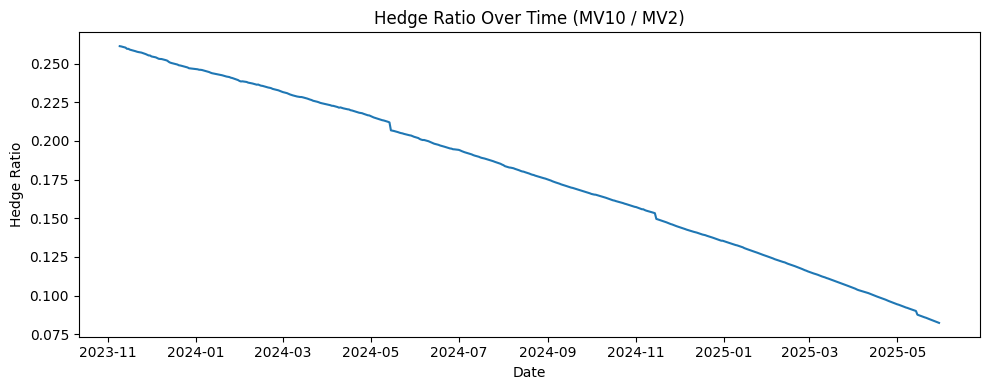

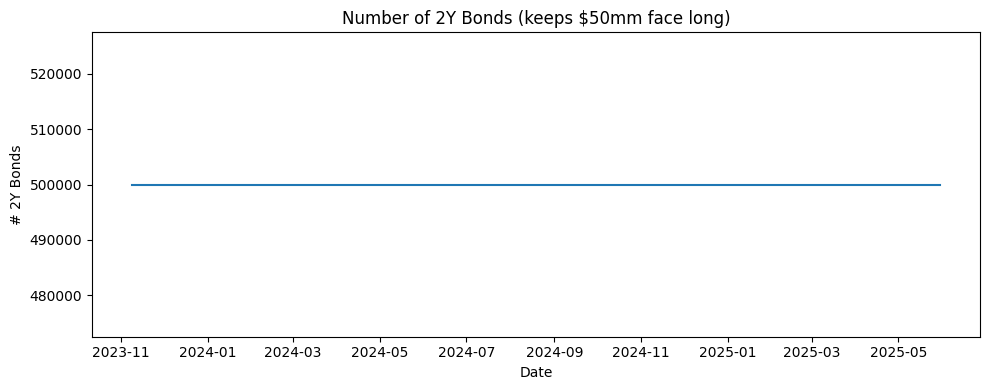

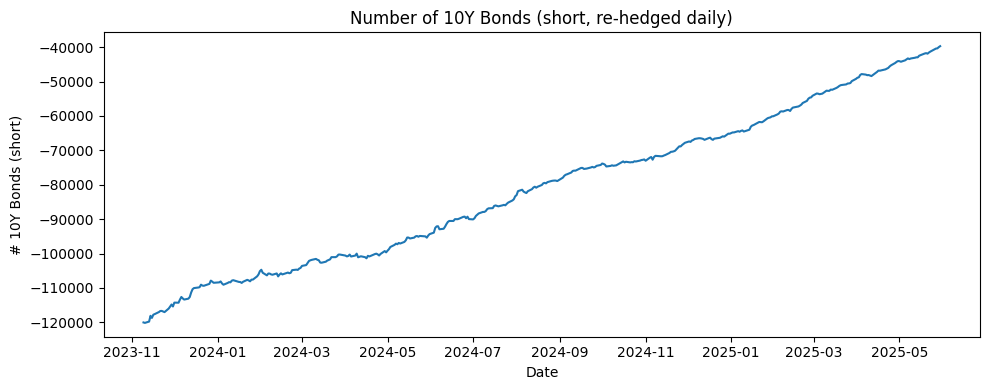

Last date in sample: 2025-05-30
Hedge ratio (MV10 / MV2): 0.0824
# 2Y bonds (long): 500,000.000
# 10Y bonds (short): -39,694.738


,hedge_ratio,n_2y,n_10y
quote date,,,
2025-05-23,0.0850,"500,000.000","-41,273.986"
2025-05-27,0.0835,"500,000.000","-40,388.341"
2025-05-28,0.0832,"500,000.000","-40,335.322"
2025-05-29,0.0828,"500,000.000","-39,976.985"
2025-05-30,0.0824,"500,000.000","-39,694.738"


In [35]:
#Re-hedge each day to keep net dollar duration = 0, then plot + report last date
NOTIONAL_LONG_2Y = 50_000_000.0   # $ face notional long in the 2Y leg (constant)
FACE_PER_BOND = 100.0

# bond IDs present in both panels
ids = list(dirty.columns.intersection(duration.columns))
if len(ids) != 2:
    raise ValueError(f"Expected 2 bond columns in both dirty & duration, found {len(ids)}: {ids}")

p_all = dirty[ids].copy()     # dirty prices per $100 face
D_all = duration[ids].copy()  # durations (years)

# keep only rows where we have both prices+durations for both bonds
valid = p_all.notna().all(axis=1) & D_all.notna().all(axis=1)
p_all = p_all.loc[valid]
D_all = D_all.loc[valid]

# identify which column is 2Y vs 10Y using average duration (10Y has larger avg duration)
avgD = D_all.mean()
id_10y = avgD.idxmax()
id_2y  = avgD.idxmin()

# constant 2Y bond count to maintain $50mm face notional long
n2 = NOTIONAL_LONG_2Y / FACE_PER_BOND

# daily MV and dollar duration for the 2Y long leg
MV2 = n2 * p_all[id_2y]
DD2 = MV2 * D_all[id_2y]

# daily short 10Y market value to offset DD2
MV10 = DD2 / D_all[id_10y]
n10 = MV10 / p_all[id_10y]  # magnitude

# hedge ratio: short 10Y market value per $1 of 2Y market value (common definition)
hedge_ratio = MV10 / MV2

# assemble results
res = pd.DataFrame(
    {
        "hedge_ratio": hedge_ratio,   # MV10 / MV2
        "n_2y": n2,                   # constant
        "n_10y": -n10,                # negative = short
    },
    index=p_all.index,
).sort_index()

# ---- plots ----
plt.figure(figsize=(10, 4))
plt.plot(res.index, res["hedge_ratio"])
plt.title("Hedge Ratio Over Time (MV10 / MV2)")
plt.xlabel("Date")
plt.ylabel("Hedge Ratio")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(res.index, res["n_2y"])
plt.title("Number of 2Y Bonds (keeps $50mm face long)")
plt.xlabel("Date")
plt.ylabel("# 2Y Bonds")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(res.index, res["n_10y"])
plt.title("Number of 10Y Bonds (short, re-hedged daily)")
plt.xlabel("Date")
plt.ylabel("# 10Y Bonds (short)")
plt.tight_layout()
plt.show()

# ---- report last date ----
last_dt = res.index.max()
last_vals = res.loc[last_dt]

print(f"Last date in sample: {last_dt:%Y-%m-%d}")
print(f"Hedge ratio (MV10 / MV2): {last_vals['hedge_ratio']:.4f}")
print(f"# 2Y bonds (long): {last_vals['n_2y']:,.3f}")
print(f"# 10Y bonds (short): {last_vals['n_10y']:,.3f}")

display(res.tail().style.format({
    "hedge_ratio": "{:.4f}",
    "n_2y": "{:,.3f}",
    "n_10y": "{:,.3f}",
}).format_index("{:%Y-%m-%d}"))


### 1.3.

Calculate the profit and loss of your trade.

Be careful to note that your positioning at time $t$ is scaled by the price change from $t$ to $t+1$. (Your profit today depends on your positioning yesterday.)

Report the first and last day's profit for the 2yr, 10yr, and net difference.

### 1.4.

Plot the PnL over time for your positioning in the...
* 2yr
* 10yr
* net

In [36]:
#1.3: Calculate PnL

# Align prices and positions
prices = p_all[[id_2y, id_10y]].copy()
positions = res[["n_2y", "n_10y"]].copy()

# Price changes (ΔP_t = P_t − P_{t-1})
dP = prices.diff()

# Shift positions so P&L at t uses position from t-1
pos_lag = positions.shift(1)

# Daily P&L by leg
pnl_2y = pos_lag["n_2y"] * dP[id_2y]
pnl_10y = pos_lag["n_10y"] * dP[id_10y]

# Net P&L
pnl_net = pnl_2y + pnl_10y

# Collect results
pnl = pd.DataFrame(
    {
        "PnL 2Y": pnl_2y,
        "PnL 10Y": pnl_10y,
        "PnL Net": pnl_net,
    },
    index=prices.index,
).dropna()

# ---- Report first and last day ----
first_dt = pnl.index.min()
last_dt = pnl.index.max()

print("First day P&L:")
print(pnl.loc[first_dt].round(2))
print("\nLast day P&L:")
print(pnl.loc[last_dt].round(2))

display(
    pnl.loc[[first_dt, last_dt]]
    .style.format("${:,.2f}")
    .format_index("{:%Y-%m-%d}")
)

First day P&L:
PnL 2Y    -19021.74
PnL 10Y    25318.82
PnL Net     6297.08
Name: 2023-11-10 00:00:00, dtype: float64

Last day P&L:
PnL 2Y     15615.86
PnL 10Y   -11498.14
PnL Net     4117.72
Name: 2025-05-30 00:00:00, dtype: float64


,PnL 2Y,PnL 10Y,PnL Net
quote date,,,
2023-11-10,"$-19,021.74","$25,318.82","$6,297.08"
2025-05-30,"$15,615.86","$-11,498.14","$4,117.72"


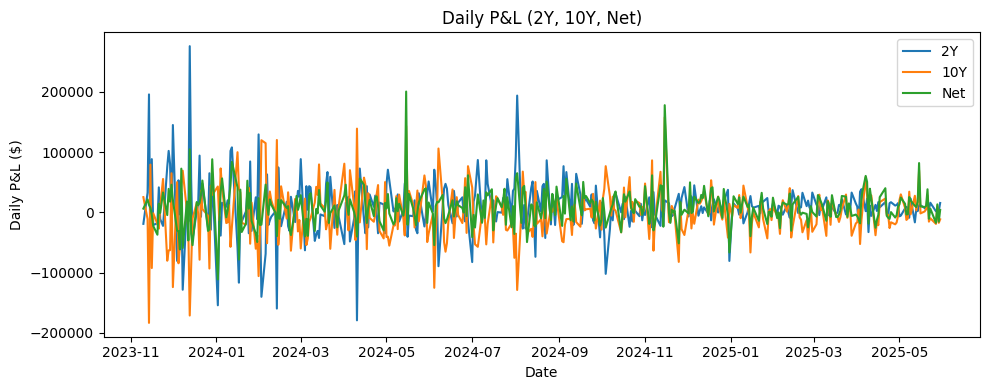

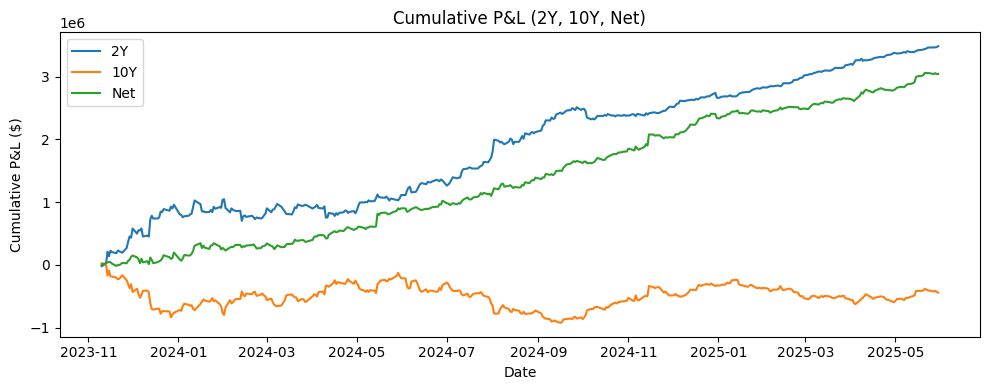

In [37]:
#1.4: Plot

# Daily P&L (three lines)
plt.figure(figsize=(10, 4))
plt.plot(pnl.index, pnl["PnL 2Y"], label="2Y")
plt.plot(pnl.index, pnl["PnL 10Y"], label="10Y")
plt.plot(pnl.index, pnl["PnL Net"], label="Net")
plt.title("Daily P&L (2Y, 10Y, Net)")
plt.xlabel("Date")
plt.ylabel("Daily P&L ($)")
plt.legend()
plt.tight_layout()
plt.show()

# Cumulative P&L (three lines)
cum_pnl = pnl.cumsum()

plt.figure(figsize=(10, 4))
plt.plot(cum_pnl.index, cum_pnl["PnL 2Y"], label="2Y")
plt.plot(cum_pnl.index, cum_pnl["PnL 10Y"], label="10Y")
plt.plot(cum_pnl.index, cum_pnl["PnL Net"], label="Net")
plt.title("Cumulative P&L (2Y, 10Y, Net)")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L ($)")
plt.legend()
plt.tight_layout()
plt.show()

### 1.5.

Your profit above ignored coupons.

Calculate the timeseries of coupons for the 2yr and 10yr. Add these coupons to the net PnL calculated above.
* Report the cumulative profit over the entire sample with the coupons, compared to your answer above without the coupons.

#### Hint
1. Calculate the dates which have coupons by looking for dates where the clean and dirty price matches. The prior date was a coupon, at the coupon rate given in the `info` tab.

1. Be careful to scale the coupons by the number of bonds held on the prior day. (Coupon at $t$ depends on positioning at $t-1$.)

In [38]:
FACE = 100.0
FREQ = 2  # semiannual coupons

ids = list(clean.columns.intersection(dirty.columns).intersection(duration.columns))
if len(ids) != 2:
    raise ValueError(f"Expected 2 bond columns shared by clean/dirty/duration, found {len(ids)}: {ids}")

avgD = duration[ids].mean(numeric_only=True)
id_10y = avgD.idxmax()
id_2y  = avgD.idxmin()

# Extract coupon rates
cpn_rate_2y  = float(info.loc["cpn rate", id_2y])
cpn_rate_10y = float(info.loc["cpn rate", id_10y])

# coupon per bond per payment date ($, per $100 face)
cpn2  = FACE * cpn_rate_2y / FREQ
cpn10 = FACE * cpn_rate_10y / FREQ

# Coupon payment indicator: clean == dirty implies coupon just paid (over prior day) 
AI_2y  = (dirty[id_2y]  - clean[id_2y]).astype(float)
AI_10y = (dirty[id_10y] - clean[id_10y]).astype(float)

tol_ai = 0.01      # "near zero" accrued: 1 cent in price points
tol_prev = 0.10    # yesterday accrued must be non-trivial (prevents false positives)

coupon_flag = pd.DataFrame(
    {
        id_2y:  (AI_2y.abs()  <= tol_ai) & (AI_2y.abs().shift(1)  >= tol_prev),
        id_10y: (AI_10y.abs() <= tol_ai) & (AI_10y.abs().shift(1) >= tol_prev),
    },
    index=clean.index,
).fillna(False)
# Coupon was paid between t-1 and t → book it on t using yesterday’s holdings
coupon_flag = coupon_flag.shift(-1).fillna(False)


# Coupons depend on prior day's holdings
pos_lag = res[["n_2y", "n_10y"]].shift(1)

# Use actual accrued interest just BEFORE coupon reset as the coupon cashflow per bond
AI_2y  = (dirty[id_2y]  - clean[id_2y]).astype(float)
AI_10y = (dirty[id_10y] - clean[id_10y]).astype(float)

coupon_cf = pd.DataFrame(index=clean.index)
coupon_cf["Coupon 2Y"] = coupon_flag[id_2y].astype(float) * (AI_2y.shift(1))  * pos_lag["n_2y"]
coupon_cf["Coupon 10Y"] = coupon_flag[id_10y].astype(float) * (AI_10y.shift(1)) * pos_lag["n_10y"]
coupon_cf["Coupon Net"] = coupon_cf["Coupon 2Y"] + coupon_cf["Coupon 10Y"]

coupon_cf = coupon_cf.reindex(pnl.index).fillna(0.0)


# Add coupons to daily PnL
pnl_with_coupons = pd.DataFrame(index=pnl.index)
pnl_with_coupons["2Y"]  = pnl["PnL 2Y"]  + coupon_cf["Coupon 2Y"]
pnl_with_coupons["10Y"] = pnl["PnL 10Y"] + coupon_cf["Coupon 10Y"]
pnl_with_coupons["Net"] = pnl["PnL Net"] + coupon_cf["Coupon Net"]

# Cumulative profit over entire sample: with vs without coupons
tot_no_cpn = pd.Series({"2Y": pnl["PnL 2Y"].sum(), "10Y": pnl["PnL 10Y"].sum(), "Net": pnl["PnL Net"].sum()})
tot_w_cpn  = pd.Series({"2Y": pnl_with_coupons["2Y"].sum(), "10Y": pnl_with_coupons["10Y"].sum(), "Net": pnl_with_coupons["Net"].sum()})

comparison_15 = pd.DataFrame(
    {
        "Without Coupons": tot_no_cpn,
        "With Coupons": tot_w_cpn,
        "Coupon Contribution": (tot_w_cpn - tot_no_cpn),
    }
)

display(
    comparison_15.style.format("${:,.0f}")
    .set_caption("Cumulative PnL Over Sample: With vs Without Coupons")
)

print(f"Net cumulative WITHOUT coupons: ${tot_no_cpn['Net']:,.2f}")
print(f"Net cumulative WITH coupons:    ${tot_w_cpn['Net']:,.2f}")

/var/folders/1_/gb2cs27x3nq4pp7f6whksw7h0000gn/T/ipykernel_52937/2222718535.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coupon_flag = coupon_flag.shift(-1).fillna(False)


,Without Coupons,With Coupons,Coupon Contribution
2Y,"$3,485,370","$3,761,508","$276,138"
10Y,"$-441,706","$-911,788","$-470,082"
Net,"$3,043,663","$2,849,720","$-193,944"


Net cumulative WITHOUT coupons: $3,043,663.49
Net cumulative WITH coupons:    $2,849,719.98


***